# Scenario-1 Evaluation (Formula 13/14)

This notebook evaluates a trained Scenario-1 SRUNet run and computes metrics using:

- `MAE = (1/(N*L*W)) * sum(|S - O|)`
- `RMSE = sqrt((1/(N*L*W)) * sum((S - O)^2))`

where `N` is number of test samples, `L` is latitude size, and `W` is longitude size.


In [1]:
# ==============================
# Inputs
# ==============================
from pathlib import Path

# Example input from user:
# RUN_DIR_INPUT = "runs/20260410_111344_lead1d"
RUN_DIR_INPUT = "runs/20260414_120329_lead1d"

# Scenario-1 data files
FORECAST_PATH = "data/ifs_lowres_indonesia_2018-2022.zarr"
TRUTH_PATH    = "data/era5_indonesia_2018-2022.zarr"

# Optional override (None = read from run config.json)
TEST_START_DATE_OVERRIDE = None
TEST_END_DATE_OVERRIDE   = None

# Variables in fixed order
VARS = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "total_precipitation_24hr",
]
VAR_LABELS = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]
TP_IDX = VARS.index("total_precipitation_24hr")

RUN_DIR = Path(RUN_DIR_INPUT)
if not RUN_DIR.exists():
    raise FileNotFoundError(
        f"Run dir not found: {RUN_DIR}. "
        f"Set RUN_DIR_INPUT to a valid path (example: runs/20260410_111344_lead1d)."
    )

print("Using RUN_DIR:", RUN_DIR)


Using RUN_DIR: runs/20260414_120329_lead1d


In [2]:
# ==============================
# Imports + run config
# ==============================
import json
import numpy as np
import pandas as pd
import xarray as xr
import torch
import torch.nn as nn
import torch.nn.functional as F

CFG_PATH = RUN_DIR / "config.json"
CKPT_PATH = RUN_DIR / "best_model.pt"

if not CKPT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint not found: {CKPT_PATH}")

cfg = {}
if CFG_PATH.exists():
    cfg = json.loads(CFG_PATH.read_text(encoding="utf-8"))

lead_days = int(cfg.get("lead_days", 1))
scale = int(cfg.get("scale", 6))

test_start_date = TEST_START_DATE_OVERRIDE or cfg.get("test_start_date", "2022-07-01")
test_end_date   = TEST_END_DATE_OVERRIDE   or cfg.get("test_end_date", "2022-12-31")

print("lead_days:", lead_days)
print("scale:", scale)
print("test range:", test_start_date, "->", test_end_date)
print("checkpoint:", CKPT_PATH)

from torch.utils.data import TensorDataset, DataLoader


lead_days: 1
scale: 6
test range: 2022-07-01 -> 2022-12-31
checkpoint: runs/20260414_120329_lead1d/best_model.pt


In [3]:
# ==============================
# Model definition (same structure as sc1_unet)
# ==============================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch))
    def forward(self, x):
        return self.net(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        dy = skip.shape[2] - x.shape[2]
        dx = skip.shape[3] - x.shape[3]
        x = F.pad(x, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

class UpscaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(in_ch, in_ch // 2, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_ch // 2),
            nn.ReLU(inplace=True),
        )
        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=3, mode="bilinear", align_corners=False),
            nn.Conv2d(in_ch // 2, in_ch // 4, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_ch // 4),
            nn.ReLU(inplace=True),
        )
        self.refine = nn.Conv2d(in_ch // 4, out_ch, kernel_size=3, padding=1)
    def forward(self, x):
        x = self.up1(x)
        x = self.up2(x)
        return self.refine(x)

class SRUNet(nn.Module):
    def __init__(self, in_ch=4, out_ch=4, base_ch=64):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base_ch)
        self.enc2 = Down(base_ch, base_ch * 2)
        self.enc3 = Down(base_ch * 2, base_ch * 4)
        self.bottleneck = Down(base_ch * 4, base_ch * 8)
        self.dec3 = Up(base_ch * 8, base_ch * 4)
        self.dec2 = Up(base_ch * 4, base_ch * 2)
        self.dec1 = Up(base_ch * 2, base_ch)
        self.sr_head = UpscaleBlock(base_ch, out_ch)
    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        b  = self.bottleneck(s3)
        d3 = self.dec3(b, s3)
        d2 = self.dec2(d3, s2)
        d1 = self.dec1(d2, s1)
        return self.sr_head(d1)


In [4]:
# ==============================
# Load Scenario-1 data + align + split test
# ==============================
ds_forecast = xr.open_dataset(FORECAST_PATH)
ds_truth = xr.open_dataset(TRUTH_PATH)

lead_td = np.timedelta64(lead_days, "D")
ds_forecast = ds_forecast.sel(prediction_timedelta=lead_td)

# Sort latitude for stable slicing
ds_truth = ds_truth.sortby("latitude")
ds_forecast = ds_forecast.sortby("latitude")

# Spatial crop logic (same as training notebook)
tr_lons = ds_truth.longitude.values
tr_lats = ds_truth.latitude.values
fc_lons = ds_forecast.longitude.values
fc_lats = ds_forecast.latitude.values

valid_lons = fc_lons[(fc_lons >= tr_lons.min()) & (fc_lons <= tr_lons.max())]
valid_lats = fc_lats[(fc_lats >= tr_lats.min()) & (fc_lats <= tr_lats.max())]

lon_start = valid_lons[0]
lat_start = valid_lats[0]

lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))

avail_lon = len(tr_lons) - lon_start_idx
avail_lat = len(tr_lats) - lat_start_idx
max_fc_lon = min(avail_lon // scale, 32)
max_fc_lat = min(avail_lat // scale, 24)

fc_lon_start_idx = np.argmin(np.abs(fc_lons - lon_start))
fc_lat_start_idx = np.argmin(np.abs(fc_lats - lat_start))

ds_fc = ds_forecast.isel(
    longitude=slice(fc_lon_start_idx, fc_lon_start_idx + max_fc_lon),
    latitude=slice(fc_lat_start_idx, fc_lat_start_idx + max_fc_lat),
)

ds_tr = ds_truth.isel(
    longitude=slice(lon_start_idx, lon_start_idx + len(ds_fc.longitude) * scale),
    latitude=slice(lat_start_idx, lat_start_idx + len(ds_fc.latitude) * scale),
)

# Temporal alignment
valid_time = ds_fc.time + lead_td
common_times = np.intersect1d(valid_time.values, ds_tr.time.values)

ds_fc = ds_fc.assign_coords(valid_time=valid_time).sel(valid_time=common_times)
ds_fc = ds_fc.assign_coords(time=ds_fc.valid_time).drop_vars("valid_time")
ds_tr_aligned = ds_tr.sel(time=common_times)

# Build arrays
X = np.stack([ds_fc[v].values for v in VARS], axis=1).astype(np.float32)   # (N,C,24,32)
Y = np.stack([ds_tr_aligned[v].values for v in VARS], axis=1).astype(np.float32)  # (N,C,144,192)

# Fill NaNs in X per-channel
for c in range(X.shape[1]):
    ch = X[:, c, :, :]
    mask = np.isnan(ch)
    if mask.any():
        fill_val = np.nanmean(ch)
        ch[mask] = fill_val
        X[:, c, :, :] = ch

# Axis fix (if needed)
expected_h = X.shape[2] * scale
expected_w = X.shape[3] * scale
if Y.shape[2] == expected_w and Y.shape[3] == expected_h:
    Y = np.transpose(Y, (0, 1, 3, 2))

# Log1p precipitation channel (same preprocessing as training)
X[:, TP_IDX] = np.log1p(np.clip(X[:, TP_IDX], 0, None))
Y[:, TP_IDX] = np.log1p(np.clip(Y[:, TP_IDX], 0, None))

# Date-based test split
times = ds_fc.time.values
test_mask = (times >= np.datetime64(test_start_date)) & (times <= np.datetime64(test_end_date))
assert test_mask.any(), "No test samples found for selected test date range"

X_test = X[test_mask]
Y_test = Y[test_mask]
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)


X_test shape: (367, 4, 32, 24)
Y_test shape: (367, 4, 192, 144)


In [5]:
# ==============================
# Inference prep from checkpoint
# ==============================
checkpoint = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
state = checkpoint['model_state']

# Infer base channels from first conv if possible
base_ch = int(state.get('enc1.net.0.weight', torch.empty(64, 4, 3, 3)).shape[0])
model = SRUNet(in_ch=len(VARS), out_ch=len(VARS), base_ch=base_ch)
model.load_state_dict(state)
model.eval()

# Normalization stats from checkpoint (torch tensors)
norm_stats = {
    'X_mean': checkpoint['X_mean'].detach().cpu().float(),
    'X_std' : checkpoint['X_std'].detach().cpu().float(),
    'Y_mean': checkpoint['Y_mean'].detach().cpu().float(),
    'Y_std' : checkpoint['Y_std'].detach().cpu().float(),
}

X_mu = norm_stats['X_mean'].numpy().astype(np.float32)
X_sig = norm_stats['X_std'].numpy().astype(np.float32)
Y_mu = norm_stats['Y_mean'].numpy().astype(np.float32)
Y_sig = norm_stats['Y_std'].numpy().astype(np.float32)

def denormalize(tensor, mu, sig, tp_idx=TP_IDX):
    # Reverse z-score, then expm1 on the TP channel.
    mu = mu.to(tensor.device)
    sig = sig.to(tensor.device)
    out = tensor * (sig + 1e-6) + mu
    out[:, tp_idx] = torch.expm1(out[:, tp_idx])
    return out

# Normalize test arrays for model and metric pipeline
X_test_norm = (X_test - X_mu) / (X_sig + 1e-6)
Y_test_norm = (Y_test - Y_mu) / (Y_sig + 1e-6)

X_test = torch.from_numpy(X_test_norm).float()
Y_test = torch.from_numpy(Y_test_norm).float()

test_loader = DataLoader(TensorDataset(X_test, Y_test), batch_size=128, shuffle=False)

VAR_LABELS_VIZ = VAR_LABELS.copy()
target_date = np.datetime64('2022-08-01')

print('Prepared tensors for evaluation:')
print('  X_test:', tuple(X_test.shape))
print('  Y_test:', tuple(Y_test.shape))


Prepared tensors for evaluation:
  X_test: (367, 4, 32, 24)
  Y_test: (367, 4, 192, 144)


[2026-04-14 12:09:45] Chart config saved -> chart_spatial_eval_config.json
[2026-04-14 12:09:52] Chart saved -> runs/20260414_120329_lead1d/srunet_eval_2022-08-01.png


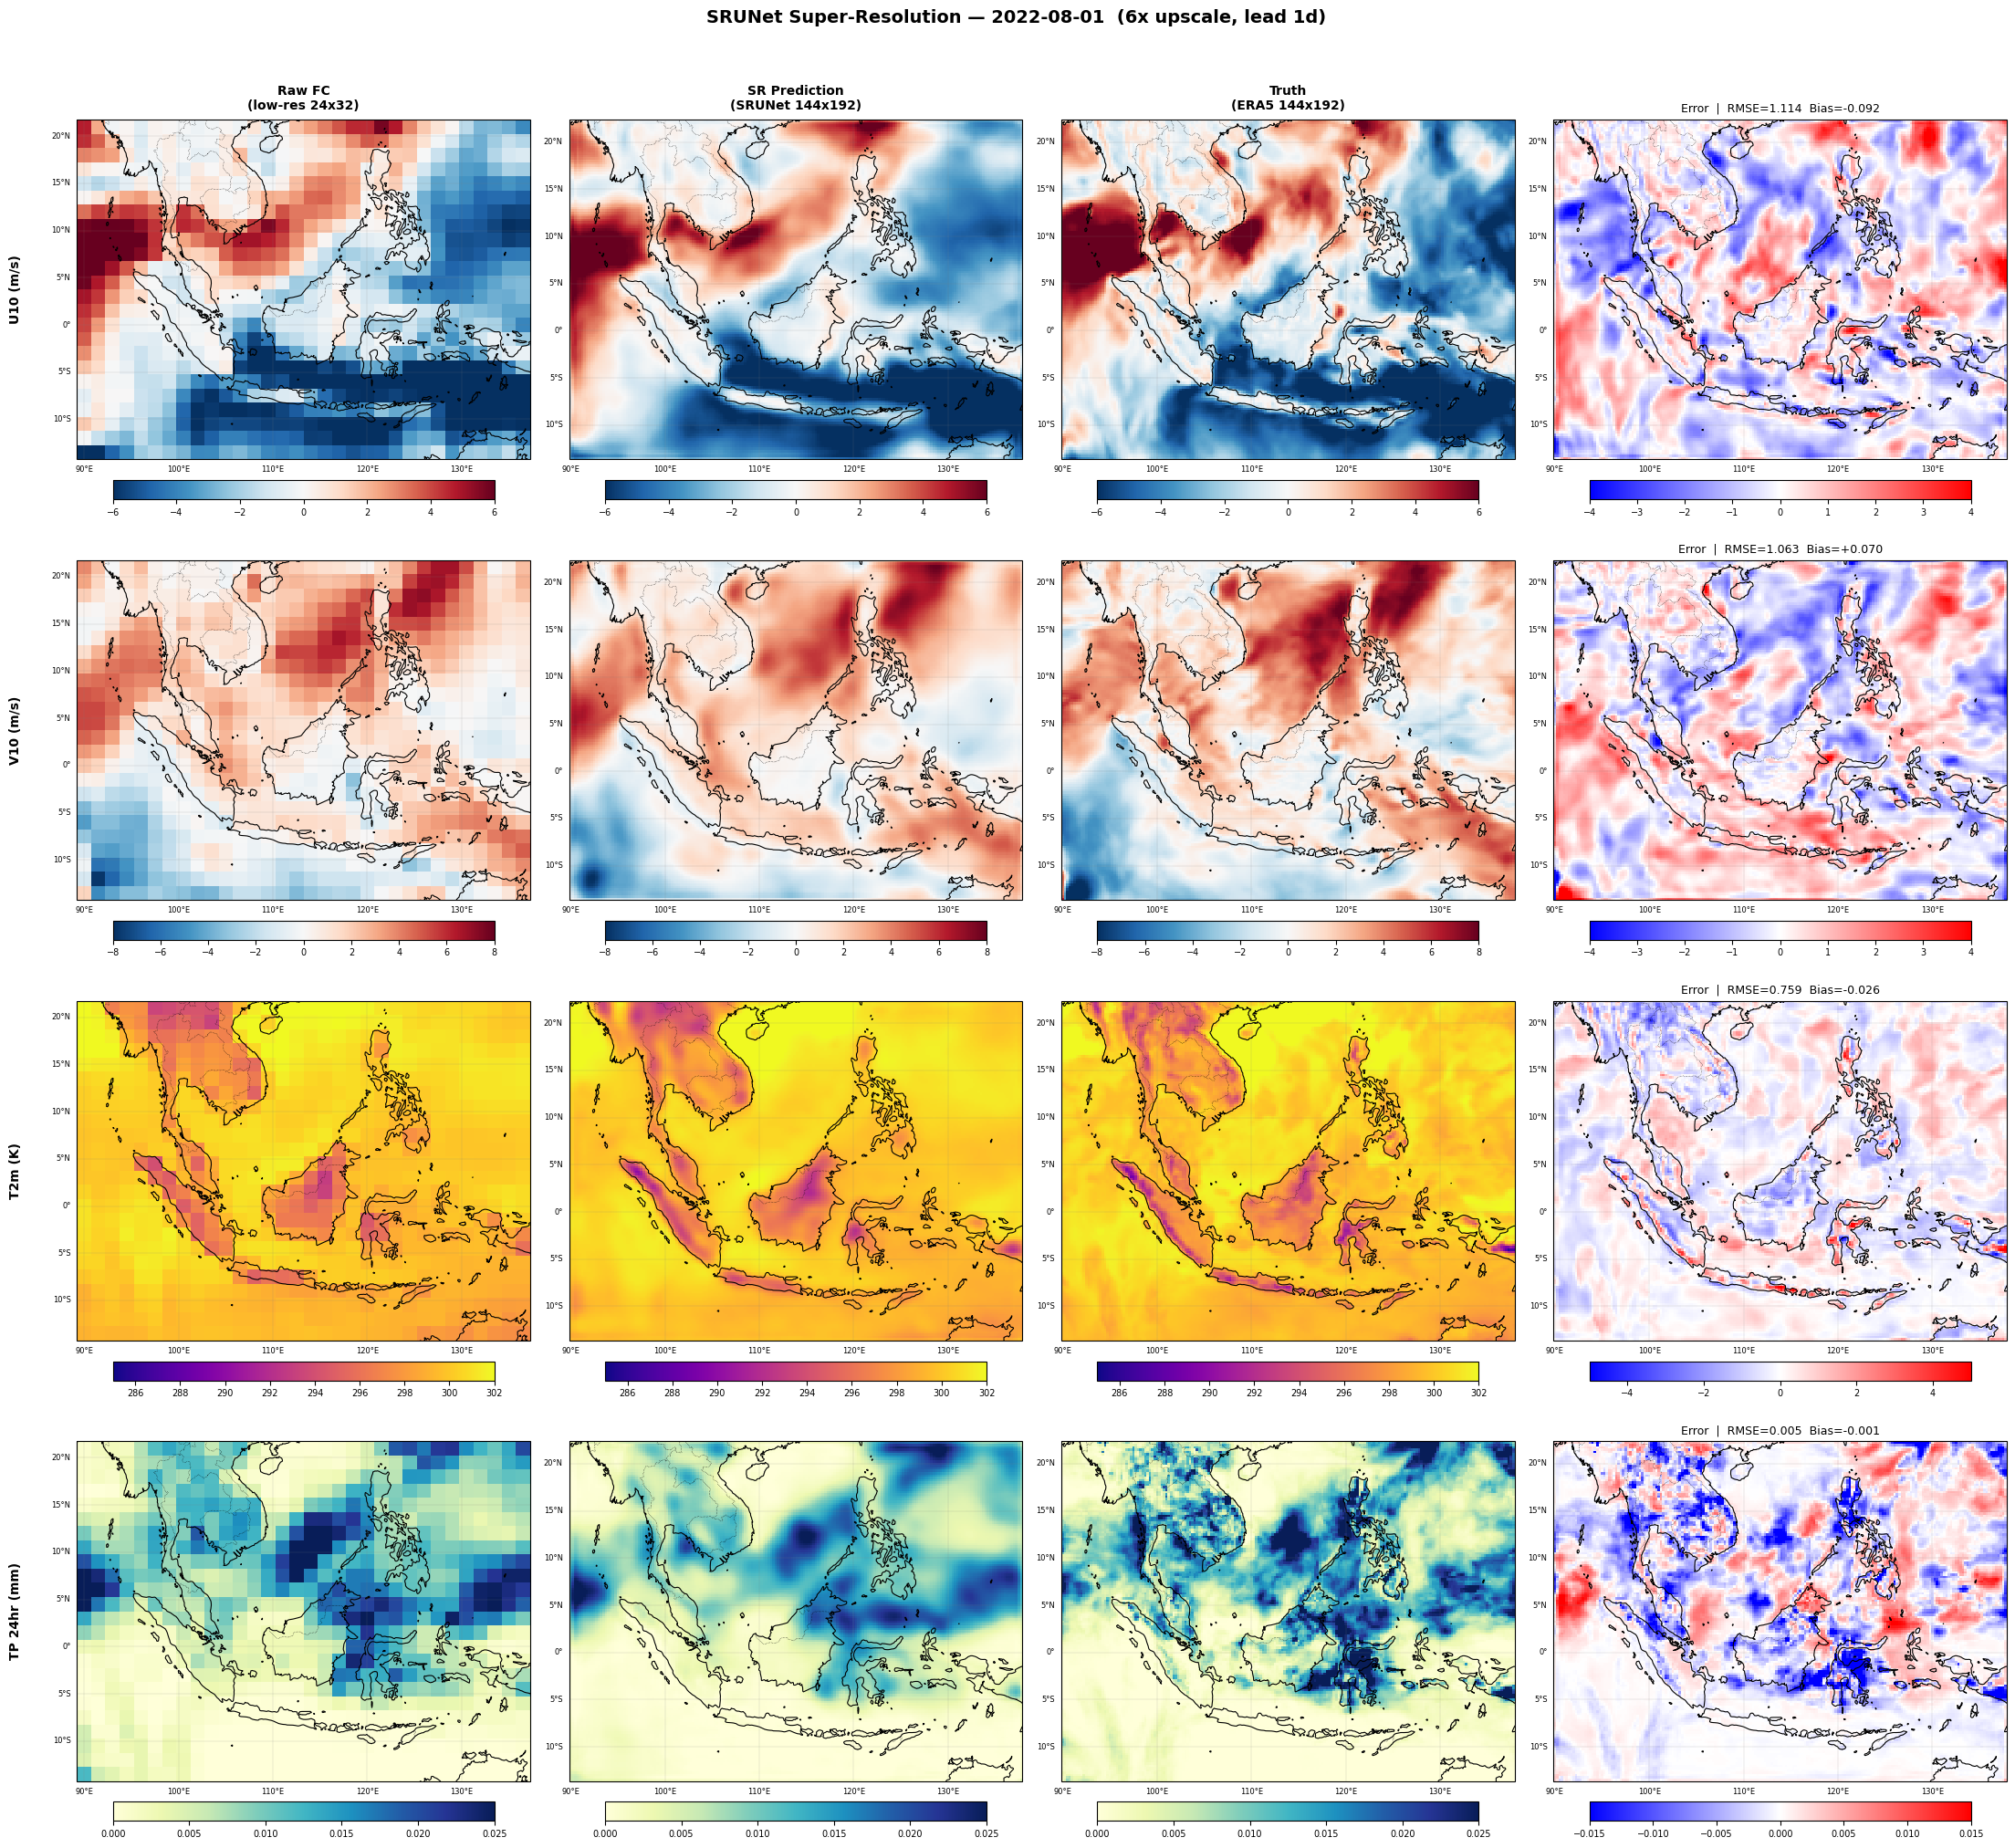

[2026-04-14 12:09:56] Loading checkpoint: runs/20260414_120329_lead1d/best_model.pt

Test Set Metrics
------------------------------------------------------------------------
[2026-04-14 12:09:57] 
Test Set Metrics
  U10 (m/s)               RMSE=  1.1962  MAE=  0.8910  Bias= -0.0362  Corr=0.9535
[2026-04-14 12:09:57]   U10 (m/s)               RMSE=  1.1962  MAE=  0.8910  Bias= -0.0362  Corr=0.9535
  V10 (m/s)               RMSE=  1.1626  MAE=  0.8639  Bias= +0.1104  Corr=0.9372
[2026-04-14 12:09:57]   V10 (m/s)               RMSE=  1.1626  MAE=  0.8639  Bias= +0.1104  Corr=0.9372
  T2m (K)                 RMSE=  0.7989  MAE=  0.5627  Bias= -0.0296  Corr=0.9257
[2026-04-14 12:09:57]   T2m (K)                 RMSE=  0.7989  MAE=  0.5627  Bias= -0.0296  Corr=0.9257
  TP 24hr (mm)            RMSE=  0.0073  MAE=  0.0035  Bias= -0.0011  Corr=0.8032
[2026-04-14 12:09:57]   TP 24hr (mm)            RMSE=  0.0073  MAE=  0.0035  Bias= -0.0011  Corr=0.8032
-----------------------------------------

In [6]:
import os
import csv as _csv
import json as _json
import datetime as _dt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch
import numpy as np
import xarray as xr

_run_start = _dt.datetime.now()
_LOG_PATH = os.path.join(str(RUN_DIR), 'runtime_eval.log')

def _log(msg: str):
    ts = _dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    line = f'[{ts}] {msg}'
    print(line)
    with open(_LOG_PATH, 'a') as f:
        f.write(line + '\n')

def save_fig(fig, name: str, dpi: int = 150):
    out = os.path.join(str(RUN_DIR), name)
    fig.savefig(out, dpi=dpi, bbox_inches='tight')
    _log(f'Chart saved -> {out}')
    return out


# Hardcoded color ranges (consistent across notebooks for head-to-head)
#                   U10    V10    T2m       TP
FIELD_VMIN = [      -6,    -8,   285,   0.000]
FIELD_VMAX = [       6,     8,   302,   0.025]
ERROR_LIM  = [       4,     4,     5,   0.015]

# Colormaps — same as regrid notebook
cmaps_field = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

# ── Save chart config ───────────────────────────────────────────────────
_chart2_cfg = {
    'chart'          : 'spatial_eval',
    'target_date'    : str(target_date),
    'lead_days'      : lead_days,
    'figsize'        : [22, 20],
    'FIELD_VMIN'     : FIELD_VMIN,
    'FIELD_VMAX'     : FIELD_VMAX,
    'ERROR_LIM'      : ERROR_LIM,
    'VAR_LABELS_VIZ' : VAR_LABELS_VIZ,
    'cmaps_field'    : cmaps_field,
}
_json.dump(_chart2_cfg, open(os.path.join(str(RUN_DIR), 'chart_spatial_eval_config.json'), 'w'), indent=2)
_log('Chart config saved -> chart_spatial_eval_config.json')


# ==============================
# Find index in test split
# ==============================
test_times = ds_tr_aligned.sel(time=slice(test_start_date, test_end_date)).time.values
idx = np.where(test_times == target_date)[0]
if len(idx) == 0:
    raise ValueError(
        f"{target_date} not found in test set.\n"
        f"Available range: {test_times[0]} -> {test_times[-1]}"
    )
idx = idx[0]

# ==============================
# Get sample & predict
# ==============================
device = next(model.parameters()).device
model.eval()

X_sample = X_test[[idx]].to(device)
Y_sample = Y_test[[idx]]

with torch.no_grad():
    Y_pred_sample = model(X_sample).cpu()

# Denormalize — keep T2m in Kelvin (no K→°C) to match regrid notebook
Y_mu  = norm_stats['Y_mean']
Y_sig = norm_stats['Y_std']
X_mu  = norm_stats['X_mean']
X_sig = norm_stats['X_std']

X_dn   = denormalize(X_sample.cpu(), X_mu, X_sig)[0]   # (4, 24,  32)
Y_true = denormalize(Y_sample,       Y_mu, Y_sig)[0]   # (4, 144, 192)
Y_pred = denormalize(Y_pred_sample,  Y_mu, Y_sig)[0]   # (4, 144, 192)

# ==============================
# Coordinate arrays
# ==============================
lons_lr = ds_fc.longitude.values   # (32,)
lats_lr = ds_fc.latitude.values    # (24,)
lons_hr = ds_tr_aligned.longitude.values  # (192,)
lats_hr = ds_tr_aligned.latitude.values   # (144,)

# ==============================
# Plot: 4 rows × 4 cols  (matching regrid_correction.ipynb layout)
# cols: Raw FC | Prediction (SR) | Truth (ERA5) | Error
# ==============================
proj   = ccrs.PlateCarree()
n_vars = len(VAR_LABELS_VIZ)

col_titles = [
    "Raw FC\n(low-res 24x32)",
    "SR Prediction\n(SRUNet 144x192)",
    "Truth\n(ERA5 144x192)",
    "Error\n(Pred - Truth)",
]

# Colormaps — same as regrid notebook
cmaps_field = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

fig, axes = plt.subplots(
    n_vars, 4,
    figsize=(22, 5 * n_vars),
    subplot_kw={"projection": proj},
)

for v in range(n_vars):
    # PyTorch (C, H, W) → numpy (H, W)
    raw_v  = X_dn[v].numpy()       # (24,  32)
    pred_v = Y_pred[v].numpy()     # (144, 192)
    true_v = Y_true[v].numpy()     # (144, 192)
    err_v  = pred_v - true_v

    cmap_f = cmaps_field[v]

    # Hardcoded ranges
    vmin = FIELD_VMIN[v]
    vmax = FIELD_VMAX[v]
    elim = ERROR_LIM[v]

    panels = [
        (lons_lr, lats_lr, raw_v,  cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, pred_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, true_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, err_v,  "bwr",  -elim,  elim),
    ]

    for col, (lons, lats, data, cmap, lo, hi) in enumerate(panels):
        ax = axes[v, col]

        # Ensure data shape is (n_lats, n_lons) for pcolormesh
        if data.shape != (len(lats), len(lons)):
            data = data.T

        im = ax.pcolormesh(
            lons, lats, data,
            cmap=cmap, vmin=lo, vmax=hi,
            shading="nearest",
            transform=proj,
        )
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=":")
        ax.add_feature(cfeature.LAND,      facecolor="whitesmoke", zorder=0)
        ax.add_feature(cfeature.OCEAN,     facecolor="lightcyan",  zorder=0)

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
        gl.top_labels   = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 6}
        gl.ylabel_style = {"size": 6}

        cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.046)
        cb.ax.tick_params(labelsize=7)

        if v == 0:
            ax.set_title(col_titles[col], fontsize=10, fontweight="bold", pad=8)
        if col == 0:
            ax.text(-0.15, 0.5, VAR_LABELS_VIZ[v], transform=ax.transAxes,
                    fontsize=10, fontweight="bold", va="center", rotation=90)

    # RMSE + bias on error panel
    rmse = np.sqrt(np.mean(err_v ** 2))
    bias = np.mean(err_v)
    axes[v, 3].set_title(
        f"Error  |  RMSE={rmse:.3f}  Bias={bias:+.3f}",
        fontsize=9, pad=6,
    )

fig.suptitle(
    f"SRUNet Super-Resolution — {str(target_date)[:10]}  (6x upscale, lead {lead_days}d)",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
save_fig(fig, f"srunet_eval_{str(target_date)[:10]}.png", dpi=150)
plt.show()

# ==========================================
# Helpers: compute_metrics / print_metrics
# ==========================================

def compute_metrics(preds_norm, targets_norm, Y_mu, Y_sig):
    """
    Denormalize both tensors, then compute per-variable
    RMSE, MAE, Bias, and Corr over the full (N, C, H, W) batch.
    Returns: dict  { VAR_LABELS[i]: {RMSE, MAE, Bias, Corr} }
    """
    p_dn = denormalize(preds_norm.clone(),   Y_mu, Y_sig).numpy()  # (N,C,H,W)
    t_dn = denormalize(targets_norm.clone(), Y_mu, Y_sig).numpy()

    results = {}
    for vi, label in enumerate(VAR_LABELS):
        p = p_dn[:, vi]; t = t_dn[:, vi]
        rmse = float(np.sqrt(np.mean((p - t) ** 2)))
        mae  = float(np.mean(np.abs(p - t)))
        bias = float(np.mean(p - t))
        pd_  = p - p.mean(); td_ = t - t.mean()
        with np.errstate(divide='ignore', invalid='ignore'):
            corr = float(
                np.sum(pd_ * td_) /
                (np.sqrt(np.sum(pd_**2) * np.sum(td_**2)) + 1e-12)
            )
        results[label] = {'RMSE': rmse, 'MAE': mae, 'Bias': bias, 'Corr': corr}
    return results


def print_metrics(metrics: dict, prefix: str = 'Metrics'):
    hdr  = f"\n{prefix}"
    line = '-' * 72
    print(hdr); print(line)
    _log(hdr)
    for label, m in metrics.items():
        r, a, b, c = m['RMSE'], m['MAE'], m['Bias'], m['Corr']
        msg = (f"  {label:<22}  RMSE={r:8.4f}  MAE={a:8.4f}  "
               f"Bias={b:+8.4f}  Corr={c:6.4f}")
        print(msg); _log(msg)
    print(line)


# ==========================================
# evaluate_test — loads best checkpoint,
# runs inference on test_loader, returns
# metrics + raw prediction tensors
# ==========================================

def evaluate_test(model, test_loader, norm_stats,
                  device='cuda' if torch.cuda.is_available() else 'cpu'):
    ckpt_path = os.path.join(str(RUN_DIR), 'best_model.pt')
    _log(f'Loading checkpoint: {ckpt_path}')
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state'])
    model = model.to(device)
    model.eval()

    Y_mu  = norm_stats['Y_mean']
    Y_sig = norm_stats['Y_std']

    all_preds   = []
    all_targets = []

    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            pred = model(X_batch.to(device))
            all_preds.append(pred.cpu())
            all_targets.append(Y_batch)

    all_preds   = torch.cat(all_preds,   dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    metrics = compute_metrics(all_preds, all_targets, Y_mu, Y_sig)
    print_metrics(metrics, prefix='Test Set Metrics')
    return metrics, all_preds, all_targets


test_metrics, test_preds, test_targets = evaluate_test(
    model, test_loader, norm_stats
)

# ==============================
# Aggregate test-set evaluation
# (Corrected Spatio-Temporal Metrics)
# ==============================
Y_mu  = norm_stats['Y_mean']
Y_sig = norm_stats['Y_std']

# Denormalize model predictions/targets (physical space)
y_pred_phys = denormalize(test_preds.clone(), Y_mu, Y_sig).numpy()
y_true_phys = denormalize(test_targets.clone(), Y_mu, Y_sig).numpy()

# Build baseline exactly like QM notebook:
# low-res ds_fc test slice -> (fill NaN) -> linear interpolation to truth test grid
fc_test_lowres = ds_fc.sel(time=slice(test_start_date, test_end_date)).copy(deep=True)
tr_test_ds = ds_tr_aligned.sel(time=slice(test_start_date, test_end_date))

# Match QM NaN handling before baseline interpolation
for v_name in VARS:
    if np.isnan(fc_test_lowres[v_name].values).any():
        fill_val = float(np.nanmean(fc_test_lowres[v_name].values))
        fc_test_lowres[v_name] = fc_test_lowres[v_name].fillna(fill_val)

fc_test_lowres, tr_test_ds = xr.align(fc_test_lowres, tr_test_ds, join='inner')

# Compute baseline RMSE strictly on xarray path (same definition as QM)
baseline_rmse_by_var = {}
for v_name in VARS:
    low_da, truth_da_xr = xr.align(fc_test_lowres[v_name], tr_test_ds[v_name], join='inner')
    base_da = low_da.interp(
        latitude=truth_da_xr.latitude,
        longitude=truth_da_xr.longitude,
        method='linear',
    )
    base_da, truth_da_xr = xr.align(base_da, truth_da_xr, join='inner')

    base_v_xr = base_da.transpose('time', 'latitude', 'longitude').values
    true_v_xr = truth_da_xr.transpose('time', 'latitude', 'longitude').values
    rmse_base_grid = np.sqrt(np.mean((base_v_xr - true_v_xr) ** 2, axis=0))
    baseline_rmse_by_var[v_name] = float(np.nanmean(rmse_base_grid))

print('\n' + '=' * 100)
print(f"{'Variable':<18} | {'RMSE':>8} | {'MAE':>8} | {'Bias':>8} | {'Corr':>8} | {'Baseline RMSE':>14} | {'Skill':>8}")
print('=' * 100)

for v_idx, v_name in enumerate(VARS):
    pred_v = y_pred_phys[:, v_idx, :, :]
    true_v = y_true_phys[:, v_idx, :, :]

    n = min(pred_v.shape[0], true_v.shape[0])
    pred_v = pred_v[:n]
    true_v = true_v[:n]

    rmse_grid = np.sqrt(np.mean((pred_v - true_v) ** 2, axis=0))
    mae_grid = np.mean(np.abs(pred_v - true_v), axis=0)
    bias_grid = np.mean(pred_v - true_v, axis=0)

    pred_diff = pred_v - np.mean(pred_v, axis=0)
    true_diff = true_v - np.mean(true_v, axis=0)
    cov = np.sum(pred_diff * true_diff, axis=0)
    var_pred = np.sum(pred_diff ** 2, axis=0)
    var_true = np.sum(true_diff ** 2, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        corr_grid = cov / np.sqrt(var_pred * var_true)

    rmse = float(np.nanmean(rmse_grid))
    mae = float(np.nanmean(mae_grid))
    bias = float(np.nanmean(bias_grid))
    corr = float(np.nanmean(corr_grid))

    rmse_base = baseline_rmse_by_var[v_name]
    skill = 1.0 - (rmse / rmse_base) if rmse_base > 0 else 0.0

    label = VAR_LABELS[v_idx]
    print(f"{label:<18} | {rmse:8.4f} | {mae:8.4f} | {bias:+8.4f} | {corr:8.4f} | {rmse_base:14.4f} | {skill:+8.4f}")

print('=' * 100)
print('\nSkill > 0 means SRUNet improves over bilinear interpolation baseline.')

# ── Save final test metrics to CSV ──────────────────────────────────────
_metrics_rows = []
for v_idx, v_name in enumerate(VARS):
    _pv = y_pred_phys[:, v_idx, :, :]
    _tv = y_true_phys[:, v_idx, :, :]
    _n = min(_pv.shape[0], _tv.shape[0])
    _pv = _pv[:_n]
    _tv = _tv[:_n]

    _rmse_g = np.sqrt(np.mean((_pv - _tv) ** 2, axis=0))
    _mae_g = np.mean(np.abs(_pv - _tv), axis=0)
    _bias_g = np.mean(_pv - _tv, axis=0)
    _pd = _pv - np.mean(_pv, axis=0)
    _td = _tv - np.mean(_tv, axis=0)
    _cov = np.sum(_pd * _td, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        _corr_g = _cov / np.sqrt(np.sum(_pd**2, axis=0) * np.sum(_td**2, axis=0))

    _rmse = float(np.nanmean(_rmse_g))
    _rbase = baseline_rmse_by_var[v_name]
    _metrics_rows.append({
        'variable': v_name,
        'label': VAR_LABELS[v_idx],
        'RMSE': _rmse,
        'MAE': float(np.nanmean(_mae_g)),
        'Bias': float(np.nanmean(_bias_g)),
        'Corr': float(np.nanmean(_corr_g)),
        'Baseline_RMSE': _rbase,
        'Skill': float(1.0 - (_rmse / _rbase)) if _rbase > 0 else 0.0,
    })

_csv_path = os.path.join(str(RUN_DIR), 'metrics.csv')
_fields = ['variable', 'label', 'RMSE', 'MAE', 'Bias', 'Corr', 'Baseline_RMSE', 'Skill']
with open(_csv_path, 'w', newline='') as _f:
    _w = _csv.DictWriter(_f, fieldnames=_fields)
    _w.writeheader()
    _w.writerows(_metrics_rows)
_log(f'Metrics saved -> {_csv_path}')

# ── Save formula-13/14 metrics too ──────────────────────────────────────
def mae_formula_13(pred, obs):
    pred = np.asarray(pred, dtype=np.float64)
    obs = np.asarray(obs, dtype=np.float64)
    N, L, W = pred.shape
    return float(np.sum(np.abs(pred - obs)) / (N * L * W))

def rmse_formula_14(pred, obs):
    pred = np.asarray(pred, dtype=np.float64)
    obs = np.asarray(obs, dtype=np.float64)
    N, L, W = pred.shape
    return float(np.sqrt(np.sum((pred - obs) ** 2) / (N * L * W)))

_formula_rows = []
for vi, v_name in enumerate(VARS):
    p = y_pred_phys[:, vi, :, :]
    t = y_true_phys[:, vi, :, :]
    _formula_rows.append({
        'variable': v_name,
        'label': VAR_LABELS[vi],
        'N': int(p.shape[0]),
        'L': int(p.shape[1]),
        'W': int(p.shape[2]),
        'MAE_formula13': mae_formula_13(p, t),
        'RMSE_formula14': rmse_formula_14(p, t),
    })

_formula_csv = os.path.join(str(RUN_DIR), 'metrics_formula13_14.csv')
pd.DataFrame(_formula_rows).to_csv(_formula_csv, index=False)
_log(f'Metrics saved -> {_formula_csv}')

# ── Log run completion ───────────────────────────────────────────────────
_total = _dt.datetime.now() - _run_start
_log(f'=== Run finished  total_elapsed={str(_total).split(".")[0]} ===')
_log(f'All outputs in: {RUN_DIR}')
print(f'\nAll outputs saved to: {RUN_DIR}')


In [7]:
# Notebook refactor complete.
# Metrics are saved by the evaluation cell above.
